<a href="https://colab.research.google.com/github/financieras/articulos/blob/main/El_perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# El Perceptrón: La neurona que inició la inteligencia artificial
##  Cómo una simple fórmula matemática aprendió a tomar decisiones

## Índice

### **Sección 1: Introducción - El sueño de imitar al cerebro**
- Contexto histórico: Frank Rosenblatt y el Mark I(1957)
- Analogía biológica: neurona vs. perceptrón
- Objetivo: crear máquinas que aprendan de datos

### **Sección 2: Anatomía del Perceptrón**
- Componentes fundamentales:
  - Las entradas ($x_1, x_2, ... x_n$): los datos de entrada
  - Los pesos sinápticos ($w_1, w_2, ... w_n$): la "importancia" de cada entrada
  - El *bias* ($b$): el umbral de decisión
  - La función de activación escalón: la decisión binaria
- La fórmula esencial: $y = f(\sum w_i x_i + b)$
- Tu primer perceptrón en código (bloque práctico)
- Demostración visual: rectas que separan el espacio

### **Sección 3: Aprendiendo de los ejemplos**
- Regla de aprendizaje del Perceptrón (explicación intuitiva)
- Aplicación práctica:
  - Compuerta AND: separable linealmente
  - Compuerta OR: separable linealmente
- Visualización de rectas separadoras en el plano 2D

### **Sección 4: El problema del XOR  y la revolución de las capas**
- XOR: el problema que una sola neurona no puede resolver.
- Demostración geométrica: por qué no existe una recta separadora.
- Solución: múltiples perceptrones trabajando juntos.
- Arquitectura de dos capas para resolver XOR.
- De rectas a regiones poligonales: el poder de la composición.
- El nacimiento conceptual del perceptrón multicapa (MLP).

### **Sección 5: Conclusiones**
- El perceptrón es elegante en su simplicidad pero limitado en soledad
- La potencia surge de la conexión entre unidades simples
- Puente histórico entre la lógica booleana y el aprendizaje profundo
- Principio fundamental: a veces la complejidad emerge de lo simple

#### Mensaje final
Lo que no puede hacer una neurona artificial, lo pueden hacer varias trabajando juntas, igual que en nuestro cerebro.

## Sección 1: Introducción - El sueño de imitar al cerebro

En 1957, el psicólogo Frank Rosenblatt presentó el **Mark I Perceptron**, una máquina del tamaño de una habitación diseñada para reconocer patrones visuales simples. No era un ordenador programado con reglas, sino algo revolucionario: una máquina que **aprendía de ejemplos**.

### La inspiración biológica

Para entender el perceptrón, primero debemos mirar al cerebro humano. Nuestro cerebro contiene aproximadamente 86 mil millones de neuronas, células especializadas que se comunican entre sí formando redes inmensamente complejas. Cada neurona es, en esencia, un procesador simple:

1. **Recibe información**: A través de sus dendritas, recibe impulsos eléctricos de cientos o miles de otras neuronas.
2. **Evalúa las entradas**: Integra todas estas señales, algunas excitatorias (que impulsan la activación) y otras inhibitorias (que la frenan).
3. **Toma una decisión**: Si la suma de todas estas señales supera cierto umbral, la neurona se activa y envía su propio impulso eléctrico a través del axón.
4. **Transmite a otras neuronas**: Esta señal viaja a través de las sinapsis hacia las neuronas conectadas, propagando información.

Esta estructura tan simple, **repetida miles de millones de veces y organizada en capas y circuitos**, da lugar a fenómenos extraordinarios: pensamientos, recuerdos, emociones y nuestra capacidad de aprender del mundo que nos rodea. Una sola neurona es limitada, pero billones trabajando en conjunto producen la inteligencia.

### Del cerebro a la máquina

La idea de Rosenblatt era elegante: ¿podríamos capturar esta lógica fundamental en una ecuación matemática? El perceptrón artificial replica este proceso neuronal básico:

- Recibe **entradas numéricas** $x_1, x_2, ..., x_n$ (como las señales que llegan por las dendritas)
- Cada entrada tiene un **peso** $w_1, w_2, ..., w_n$ que determina su importancia (simulando la fuerza de las conexiones sinápticas)
- Si la suma ponderada supera un **umbral** (el bias $b$), la neurona artificial se activa
- Con cada error en sus predicciones, **ajusta sus pesos automáticamente** para mejorar

**El objetivo**: crear máquinas capaces de aprender automáticamente a clasificar, decidir y reconocer patrones sin que un humano les programe cada regla explícitamente. En lugar de decirle a la máquina "si ves esto, haz aquello", le mostramos ejemplos y ella descubre las reglas por sí misma.

Lo fascinante es que este modelo simple, inspirado directamente en la biología, sentó las bases de lo que décadas después se convertiría en el aprendizaje profundo. El perceptrón nos enseñó una lección fundamental: **la complejidad puede emerger de unidades simples trabajando juntas**.

Comencemos explorando cómo funciona esta neurona artificial.

## Sección 2: Anatomía del Perceptrón

Un perceptrón es sorprendentemente simple. Podemos descomponerlo en cuatro elementos fundamentales que trabajan en secuencia:

### Componentes fundamentales

**1. Las entradas ($x_1, x_2, ..., x_n$): los datos de entrada**

Son los valores numéricos que alimentan al perceptrón. Por ejemplo, si queremos clasificar si un email es spam:
- $x_1$ podría ser el número de palabras "gratis"
- $x_2$ podría ser el número de signos de exclamación
- $x_3$ podría ser si contiene enlaces sospechosos (0 o 1)

**2. Los pesos sinápticos ($w_1, w_2, ..., w_n$): la "importancia" de cada entrada**

Cada entrada tiene asociado un peso que indica cuánto influye en la decisión final. Un peso grande (positivo o negativo) significa que esa entrada es muy importante; un peso cercano a cero significa que es casi irrelevante.

Por ejemplo: $w_1 = 2.5$ significa que la palabra "gratis" tiene mucho peso en identificar spam, mientras que $w_3 = 0.1$ significa que los enlaces tienen poca influencia.

Estos pesos son los **parámetros que el perceptrón aprende** ajustándolos con cada ejemplo.

**3. El bias ($b$): el umbral de decisión**

El bias desplaza el umbral de activación. Sin él, la decisión siempre pasaría por el origen (0,0). Con el bias, podemos mover la frontera de decisión a donde necesitemos.

Piénsalo así: incluso si todas las entradas son cero, el bias puede hacer que el perceptrón se active o no.

**4. La función de activación escalón: la decisión binaria**

Una vez calculada la suma ponderada, necesitamos una decisión: ¿se activa o no? La función escalón es binaria:

$$
f(z) = \begin{cases}
1 & \text{si } z \geq 0 \\
0 & \text{si } z < 0
\end{cases}
$$

Si la suma ponderada es positiva o cero, devuelve 1 (activado). Si es negativa, devuelve 0 (no activado).

### La fórmula esencial

Todo el proceso del perceptrón se resume en una ecuación elegante:

$$
y = f\left(\sum_{i=1}^{n} w_i x_i + b\right)
$$

O escrito paso a paso:
1. Multiplicamos cada entrada por su peso: $w_1 x_1 + w_2 x_2 + ... + w_n x_n$
2. Sumamos el bias: $w_1 x_1 + w_2 x_2 + ... + w_n x_n + b$
3. Aplicamos la función escalón al resultado para obtener 0 o 1

### Tu primer perceptrón en código

Veamos cómo implementar un perceptrón simple en Python:

In [3]:
import numpy as np

class Perceptron:
    def __init__(self, n_inputs):
        """
        Initialize a perceptron with random weights and bias.

        Args:
            n_inputs: Number of input features
        """
        self.weights = np.random.randn(n_inputs)
        self.bias = np.random.randn()

    def activation(self, z):
        """
        Step activation function.

        Args:
            z: Weighted sum of inputs

        Returns:
            1 if z >= 0, else 0
        """
        return 1 if z >= 0 else 0

    def predict(self, x):
        """
        Make a prediction for input x.

        Args:
            x: Input array

        Returns:
            Predicted class (0 or 1)
        """
        # Calculate weighted sum
        z = np.dot(self.weights, x) + self.bias
        # Apply activation function
        return self.activation(z)

# Example: perceptron with 2 inputs
perceptron = Perceptron(n_inputs=2)

# Test with a point
point = np.array([1.5, 2.0])
prediction = perceptron.predict(point)
print(f"Prediction for {point}: {prediction}")

Prediction for [1.5 2. ]: 0


### Demostración visual: rectas que separan el espacio

Aquí está la interpretación geométrica clave: **un perceptrón con dos entradas dibuja una línea recta en el plano** que divide el espacio en dos regiones:

- Todos los puntos en un lado de la recta son clasificados como 0
- Todos los puntos en el otro lado son clasificados como 1

La ecuación de esta recta viene directamente de la condición del umbral:
$$w_1 x_1 + w_2 x_2 + b = 0$$

Veamos un ejemplo visual:

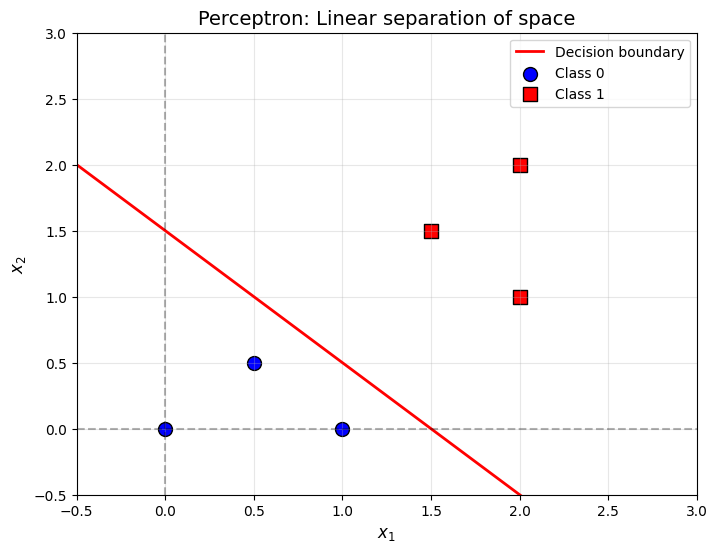

In [4]:
import matplotlib.pyplot as plt

# Create a perceptron with specific weights
weights = np.array([1, 1])
bias = -1.5

# Generate test points
x1 = np.linspace(-1, 3, 100)
x2 = -(weights[0] * x1 + bias) / weights[1]  # Solve for x2

# Visualize
plt.figure(figsize=(8, 6))
plt.plot(x1, x2, 'r-', linewidth=2, label='Decision boundary')
plt.axhline(0, color='k', linestyle='--', alpha=0.3)
plt.axvline(0, color='k', linestyle='--', alpha=0.3)

# Add some example points
class_0_points = np.array([[0, 0], [0.5, 0.5], [1, 0]])
class_1_points = np.array([[2, 2], [1.5, 1.5], [2, 1]])

plt.scatter(class_0_points[:, 0], class_0_points[:, 1],
           c='blue', s=100, marker='o', label='Class 0', edgecolors='k')
plt.scatter(class_1_points[:, 0], class_1_points[:, 1],
           c='red', s=100, marker='s', label='Class 1', edgecolors='k')

plt.xlabel('$x_1$', fontsize=12)
plt.ylabel('$x_2$', fontsize=12)
plt.title('Perceptron: Linear separation of space', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-0.5, 3)
plt.ylim(-0.5, 3)
plt.show()

**Observación crucial**: El perceptrón solo puede resolver problemas **linealmente separables**, es decir, aquellos donde podemos trazar una línea recta (o un hiperplano en dimensiones superiores) que separe perfectamente las dos clases.

En la siguiente sección veremos cómo entrenar este perceptrón para que aprenda automáticamente los pesos correctos.

## Sección 3: Aprendiendo de los ejemplos

Hasta ahora hemos visto la estructura del perceptrón, pero ¿cómo aprende? La belleza del perceptrón está en su **regla de aprendizaje**: un algoritmo simple que ajusta los pesos automáticamente basándose en sus errores.

### Regla de aprendizaje del Perceptrón (explicación intuitiva)

El proceso es sorprendentemente directo:

1. **Inicialización**: Comenzamos con pesos aleatorios
2. **Predicción**: Para cada ejemplo de entrenamiento, hacemos una predicción
3. **Comparación**: Comparamos la predicción con la respuesta correcta
4. **Ajuste**: Si nos equivocamos, ajustamos los pesos en la dirección correcta
5. **Repetición**: Repetimos hasta que clasifiquemos todos los ejemplos correctamente (o alcancemos un número máximo de iteraciones)

La regla matemática de actualización es:

$$
w_i \leftarrow w_i + \alpha \cdot (y - \hat{y}) \cdot x_i
$$

$$
b \leftarrow b + \alpha \cdot (y - \hat{y})
$$

Donde:
- $\alpha$ es la **tasa de aprendizaje** (un número pequeño, típicamente 0.01 - 0.1)
- $(y - \hat{y})$ es el **error**
- $y$ es la etiqueta real
- $\hat{y}$ es la predicción del perceptrón

**Intuición**:
- Si predecimos 0 pero debería ser 1: el error es +1, así que **incrementamos** los pesos
- Si predecimos 1 pero debería ser 0: el error es -1, así que **decrementamos** los pesos
- Si acertamos: el error es 0, no cambiamos nada

Implementemos esto en código:

In [5]:
import numpy as np

class PerceptronWithLearning:
    def __init__(self, n_inputs, learning_rate=0.1):
        """
        Initialize perceptron with learning capability.

        Args:
            n_inputs: Number of input features
            learning_rate: Step size for weight updates (alpha)
        """
        self.weights = np.random.randn(n_inputs)
        self.bias = np.random.randn()
        self.learning_rate = learning_rate

    def activation(self, z):
        """Step activation function."""
        return 1 if z >= 0 else 0

    def predict(self, x):
        """Make a prediction."""
        z = np.dot(self.weights, x) + self.bias
        return self.activation(z)

    def train(self, X, y, epochs=100):
        """
        Train the perceptron on dataset.

        Args:
            X: Training inputs (n_samples, n_features)
            y: True labels (n_samples,)
            epochs: Number of training iterations

        Returns:
            List of errors per epoch
        """
        errors_per_epoch = []

        for epoch in range(epochs):
            total_error = 0

            for xi, y_true in zip(X, y):
                # Make prediction
                y_pred = self.predict(xi)

                # Calculate error
                error = y_true - y_pred

                # Update weights and bias
                self.weights += self.learning_rate * error * xi
                self.bias += self.learning_rate * error

                # Track total error
                total_error += abs(error)

            errors_per_epoch.append(total_error)

            # Stop if perfect classification
            if total_error == 0:
                print(f"Converged in {epoch + 1} epochs")
                break

        return errors_per_epoch

### Aplicación práctica: Compuertas lógicas

Las compuertas lógicas son el ejemplo perfecto para demostrar el aprendizaje del perceptrón. Son problemas simples con patrones claros que podemos visualizar fácilmente.

#### Compuerta AND: separable linealmente

La compuerta AND devuelve 1 solo cuando **ambas** entradas son 1:

| $x_1$ | $x_2$ | AND |
|-------|-------|-----|
| 0     | 0     | 0   |
| 0     | 1     | 0   |
| 1     | 0     | 0   |
| 1     | 1     | 1   |

Entrenemos un perceptrón para aprender esta función:

In [6]:
# Training data for AND gate
X_and = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_and = np.array([0, 0, 0, 1])

# Create and train perceptron
perceptron_and = PerceptronWithLearning(n_inputs=2, learning_rate=0.1)
errors_and = perceptron_and.train(X_and, y_and, epochs=100)

# Test the trained perceptron
print("\nAND Gate - Predictions:")
for x, y_true in zip(X_and, y_and):
    y_pred = perceptron_and.predict(x)
    print(f"Input: {x} | True: {y_true} | Predicted: {y_pred}")

print(f"\nLearned weights: {perceptron_and.weights}")
print(f"Learned bias: {perceptron_and.bias:.3f}")

Converged in 4 epochs

AND Gate - Predictions:
Input: [0 0] | True: 0 | Predicted: 0
Input: [0 1] | True: 0 | Predicted: 0
Input: [1 0] | True: 0 | Predicted: 0
Input: [1 1] | True: 1 | Predicted: 1

Learned weights: [0.55130976 0.5058455 ]
Learned bias: -0.737


#### Compuerta OR: separable linealmente

La compuerta OR devuelve 1 cuando **al menos una** entrada es 1:

| $x_1$ | $x_2$ | OR |
|-------|-------|-----|
| 0     | 0     | 0   |
| 0     | 1     | 1   |
| 1     | 0     | 1   |
| 1     | 1     | 1   |

In [7]:
# Training data for OR gate
X_or = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_or = np.array([0, 1, 1, 1])

# Create and train perceptron
perceptron_or = PerceptronWithLearning(n_inputs=2, learning_rate=0.1)
errors_or = perceptron_or.train(X_or, y_or, epochs=100)

# Test the trained perceptron
print("\nOR Gate - Predictions:")
for x, y_true in zip(X_or, y_or):
    y_pred = perceptron_or.predict(x)
    print(f"Input: {x} | True: {y_true} | Predicted: {y_pred}")

Converged in 5 epochs

OR Gate - Predictions:
Input: [0 0] | True: 0 | Predicted: 0
Input: [0 1] | True: 1 | Predicted: 1
Input: [1 0] | True: 1 | Predicted: 1
Input: [1 1] | True: 1 | Predicted: 1


### Visualización de rectas separadoras en el plano 2D

Visualicemos cómo el perceptrón ha aprendido a separar los datos:

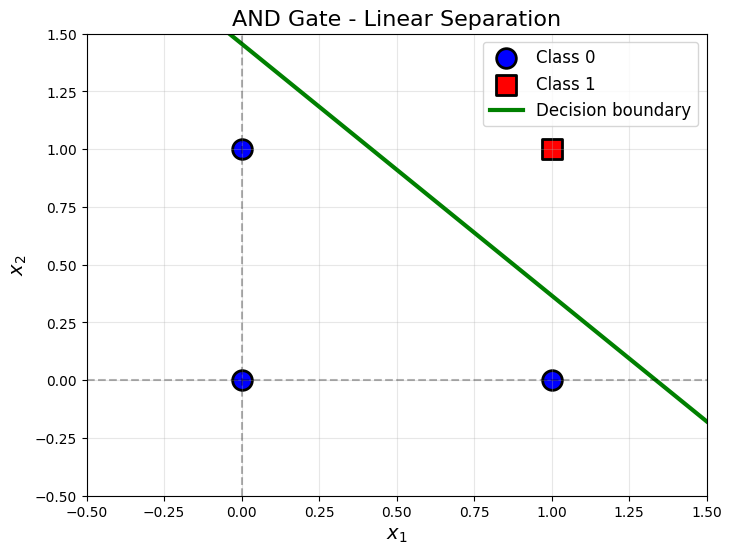

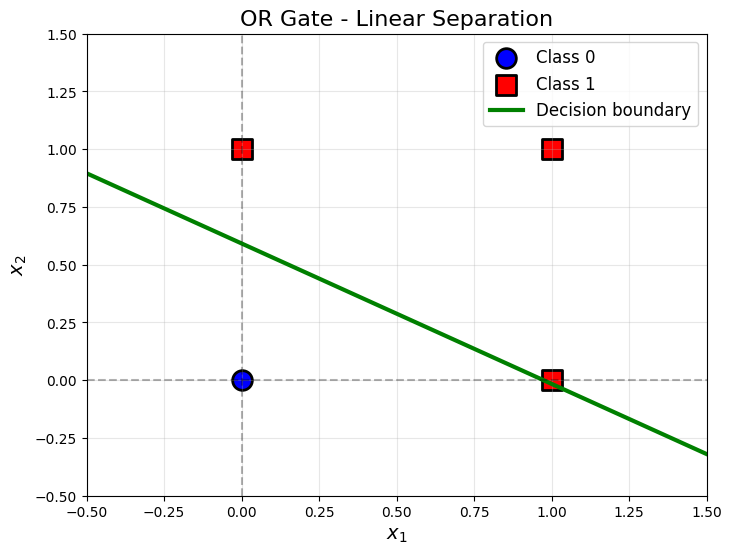

In [8]:
import matplotlib.pyplot as plt

def plot_decision_boundary(perceptron, X, y, title):
    """
    Plot the decision boundary learned by the perceptron.

    Args:
        perceptron: Trained perceptron
        X: Input data
        y: True labels
        title: Plot title
    """
    plt.figure(figsize=(8, 6))

    # Plot data points
    for i, label in enumerate([0, 1]):
        mask = y == label
        marker = 'o' if label == 0 else 's'
        color = 'blue' if label == 0 else 'red'
        plt.scatter(X[mask, 0], X[mask, 1],
                   c=color, s=200, marker=marker,
                   label=f'Class {label}', edgecolors='k', linewidth=2)

    # Plot decision boundary
    x1_vals = np.linspace(-0.5, 1.5, 100)
    # Solve for x2: w1*x1 + w2*x2 + b = 0
    if perceptron.weights[1] != 0:
        x2_vals = -(perceptron.weights[0] * x1_vals + perceptron.bias) / perceptron.weights[1]
        plt.plot(x1_vals, x2_vals, 'g-', linewidth=3, label='Decision boundary')

    plt.xlabel('$x_1$', fontsize=14)
    plt.ylabel('$x_2$', fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.axhline(0, color='k', linestyle='--', alpha=0.3)
    plt.axvline(0, color='k', linestyle='--', alpha=0.3)

    plt.show()

# Visualize both gates
plot_decision_boundary(perceptron_and, X_and, y_and, 'AND Gate - Linear Separation')
plot_decision_boundary(perceptron_or, X_or, y_or, 'OR Gate - Linear Separation')

**Observación importante**: En ambos casos (AND y OR), el perceptrón encuentra una línea recta que separa perfectamente la clase 0 de la clase 1. Esto confirma que ambos problemas son **linealmente separables**.

Pero... ¿qué sucede cuando un problema NO es linealmente separable? Esa es precisamente la pregunta que exploraremos en la siguiente sección con el famoso **problema del XOR**.